#  Data Collection

Mining prospection considers several factors, such as geochemical measurements, geology, mining facilities, sub-basins, etc.

Then, SERNAGEOMIN contains a variaty of maps dedicated to this problem.

Sources:

- https://appsngmaz.sernageomin.cl/catastro_SNGM/home/index
- https://arcgisawa.sernageomin.cl/server/rest/
- https://experience.arcgis.com/experience/90cc3e3cef914166a8b92a8322c0417b?draft=true
- https://www.arcgis.com/apps/dashboards/f47a3c43bb974de486313d2f15e70fda#
- https://www.arcgis.com/home/item.html?id=0c38d62b9ec147eb9684826e4818629a#overview

## Imports

In [1]:
# Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Environment
import os
from dotenv import load_dotenv
load_dotenv()

# Maps
import geopandas as gpd
import contextily as ctx
from arcgis.features import FeatureLayer

mapbox = ctx.providers.MapBox(
    id="mapbox/satellite-streets-v12",
    accessToken=os.getenv("MAPBOX_API_KEY")
)

## Load Data

The following datasets will be used, covering mining facilities, geochemistry, and sub-basins.

In [2]:
datasources = [
    {
        "name": "mining_facilities",
        "url": "https://arcgisawa.sernageomin.cl/server/rest/services/Instalaciones_WGS84/FeatureServer/2",
        "crs": "EPSG:4326"
    },
    {
        "name": "geochemistry_under_analysis",
        "url": "https://services1.arcgis.com/OyjvVdFTl5hfSdX3/arcgis/rest/services/Compilaci%C3%B3n_de_Geoqu%C3%ADmica_de_sedimentos_de_Chile_WFL1/FeatureServer/0",
        "crs": "EPSG:3857"
    },
    {
        "name": "geochemistry_published",
        "url": "https://services1.arcgis.com/OyjvVdFTl5hfSdX3/arcgis/rest/services/Compilaci%C3%B3n_de_Geoqu%C3%ADmica_de_sedimentos_de_Chile_WFL1/FeatureServer/1",
        "crs": "EPSG:3857"
    },
    {
        "name": "subsubbasins",
        "url": "https://services.arcgis.com/r7t1P5pnkoOLRdhr/ArcGIS/rest/services/Cuencas/FeatureServer/2",
        "crs": "EPSG:32719"
    }
]


for datasource in datasources:
    path = f"../../data/raw/{datasource['name']}_df.parquet"

    # Existing data first
    if not os.path.exists(path):
        df = FeatureLayer(datasource["url"]).query(
            where="1=1",
            out_fields="*",
            return_geometry=True,
            as_df=True
        )
        print(
            f"{datasource['name']}\n"
            f"shape: {df.shape}\n"
            f"columns: {df.columns}\n"
        )
        
        gdf = gpd.GeoDataFrame(
            df,
            geometry="SHAPE",
            crs=datasource["crs"]
        )
        gdf.to_parquet(
            path,
            index=False
        )
    else:
        df = gpd.read_parquet(path)
        print(
            f"{datasource['name']}\n"
            f"shape: {df.shape}\n"
            f"columns: {df.columns}\n"
        )

mining_facilities
shape: (37635, 34)
columns: Index(['OBJECTID', 'rut_empresa', 'nombre_empresa', 'empresa_activa',
       'region_faena', 'provincia_faena', 'comuna_faena', 'id_faena',
       'nombre_faena', 'faena_activa_sistema', 'categoria_faena',
       'region_instalacion', 'provincia_instalacion', 'comuna_instalacion',
       'id_instalacion', 'nombre_instalacion', 'tipo_instalacion',
       'recurso_minero_instalacion', 'recurso_principal_instalacion',
       'tipo_recurso_instalacion', 'utm_norte_instalacion',
       'utm_este_instalacion', 'datum_instalacion', 'huso_instalacion',
       'cota_instalacion', 'estado_instalacion', 'tabla_origen',
       'lote_sincronizacion', 'vigente_gis', 'transformacion_gis',
       'calidad_geodesica', 'observacion_gis', 'fecha_actualizacion_gis',
       'SHAPE'],
      dtype='str')

geochemistry_under_analysis
shape: (1111, 82)
columns: Index(['OBJECTID', 'Proyecto', 'Punto_de_muestreo', 'Altitud____m_s_n_m__',
       'UTM_ESTE__Sirgas_UTM_

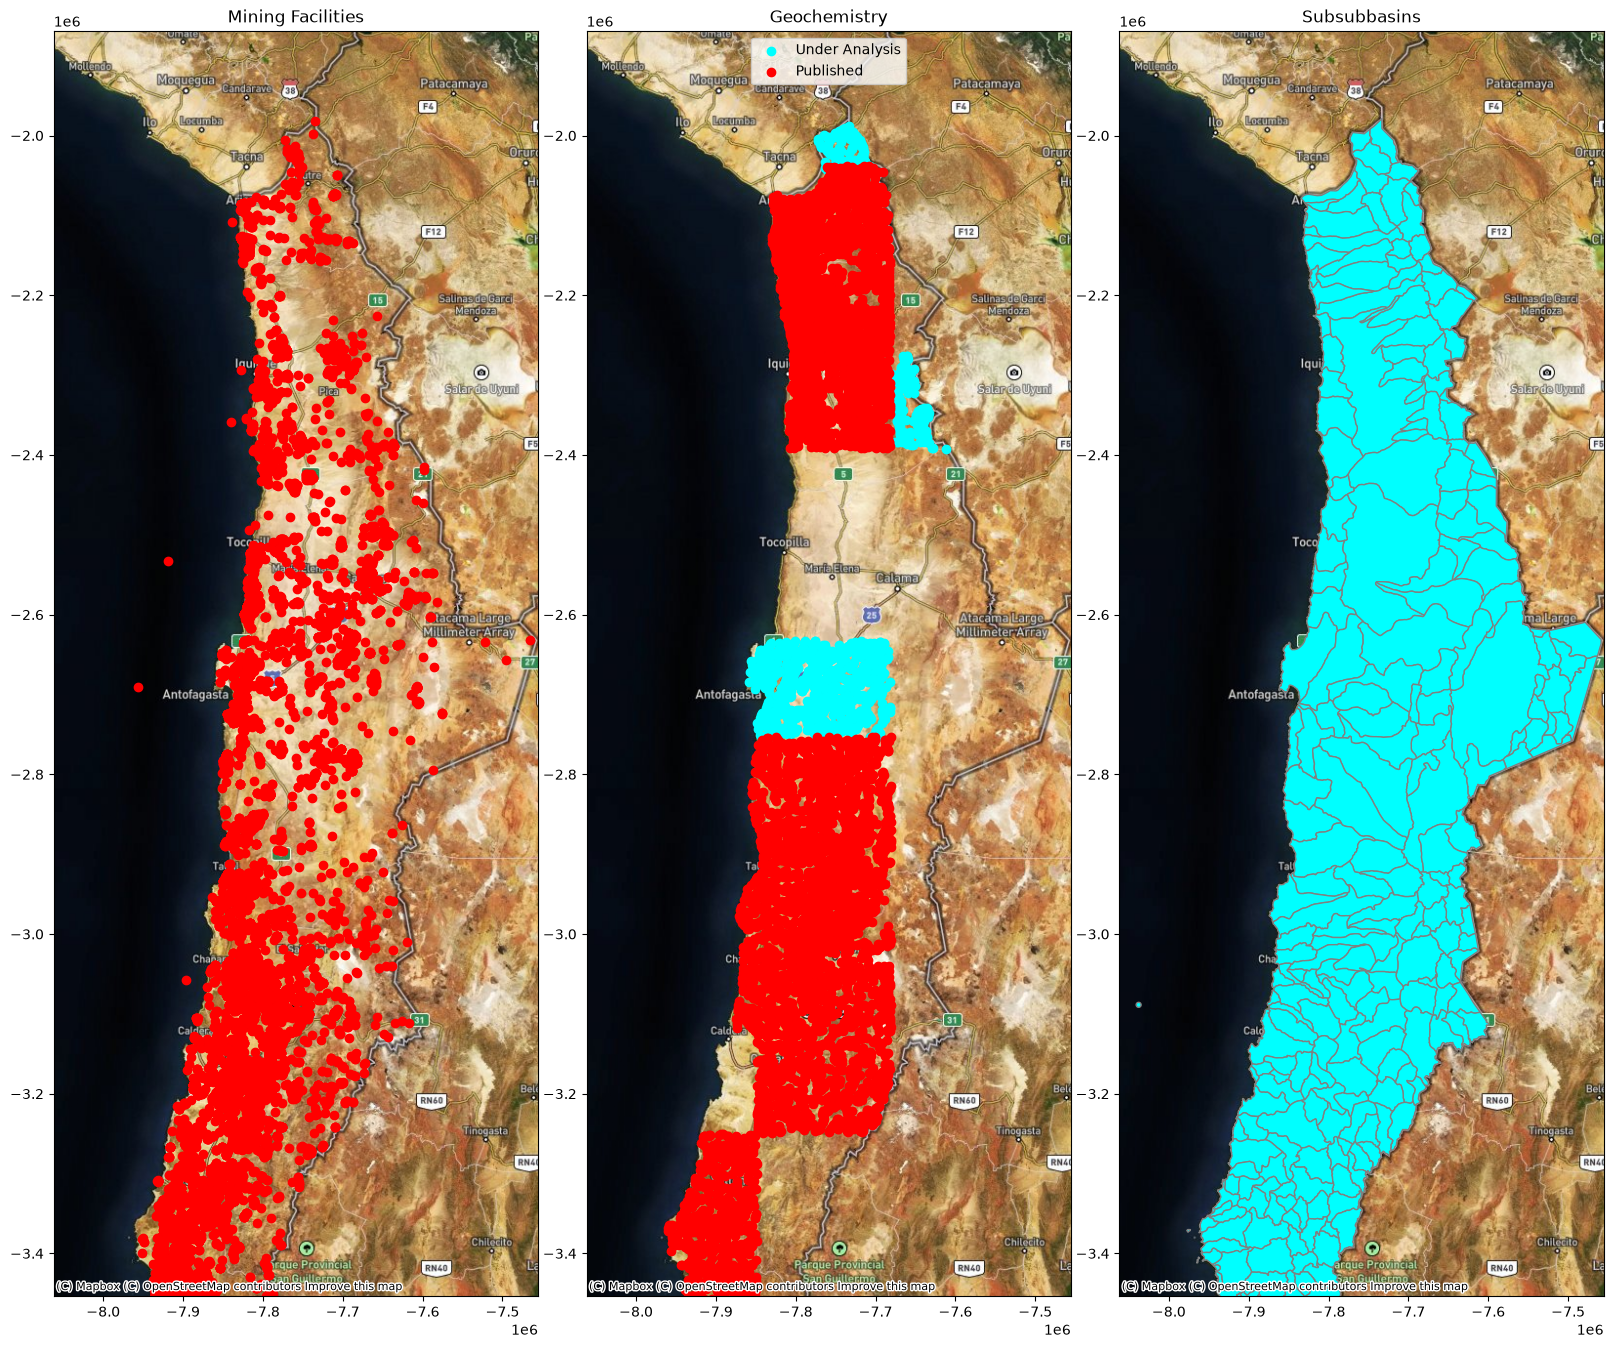

In [3]:
xlim = (-8061966.247294, -7455361.990823)
ylim = (-3453730.686037, -1868732.467516)
fig, axes = plt.subplots(1, 3, figsize=(20, 20), gridspec_kw={"wspace": 0.1})
ax1, ax2, ax3 = axes.flatten()

base_path = "../../data/raw"
# mining facilities
gdf1 = gpd.read_parquet(f"{base_path}/mining_facilities_df.parquet")
gdf1 = gdf1.to_crs(3857)
gdf1.plot(ax=ax1, color="red")
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ctx.add_basemap(ax=ax1, source=mapbox)
ax1.set_aspect("equal")
ax1.set_adjustable('box')
ax1.set_title("Mining Facilities")

# geochemistry
gdf3 = gpd.read_parquet(f"{base_path}/geochemistry_under_analysis_df.parquet")
gdf4= gpd.read_parquet(f"{base_path}/geochemistry_published_df.parquet")
gdf3.plot(ax=ax2, color='cyan', label= "Under Analysis")
gdf4.plot(ax=ax2, color='red', label= "Published")
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ctx.add_basemap(ax=ax2, source=mapbox)
ax2.set_aspect("equal")
ax2.set_adjustable('box')
ax2.set_title("Geochemistry")
ax2.legend(loc='upper center')

# subsubbasins
gdf5 = gpd.read_parquet(f"{base_path}/subsubbasins_df.parquet")
gdf5 = gdf5.to_crs(3857)
gdf5.plot(ax=ax3, facecolor="cyan", edgecolor="gray")
ax3.set_xlim(xlim)
ax3.set_ylim(ylim)
ctx.add_basemap(ax=ax3, source=mapbox)
ax3.set_aspect("equal")
ax3.set_adjustable('box')
ax3.set_title("Subsubbasins")

plt.savefig(
    "../../images/data_collection_mining_facilities_geochemistry_subsubbasins_maps.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()